The backscatter coefficient observed by an HSRL is dictated by the combination of particle scattering cross section (effectively size) and number denisty.

$\beta = \int_0^{\infty} \sigma(r) n(r) dr$

Tthis means estimating number density or size from lidar signals is not strictly possible because the above equation has no unique solution.  Never-the-less, there has been considerable effort poured into retrieving these quantities from lidar signals.  In particular, there is increasing interest in leveraging machine learning, which is often noted for its ability to provide solutions to problems that had otherwise seemed intractable.

The notion of using machine learning (including linear regression) to solve problems lacking unique solutions is that the training process leverages the the sampling statistics of the data to constrain the estimation process.  To infer number concentration from lidar backscatter and/or extinction employing machine learning assumes that while various combinations of particle size and density could explain a particular measurement, they are not all equally likely to exist.  Machine learning leverages this to obtain a prediction of what combination is likely to occur.  In otherwords, the answer that will be right more often than any other answer.

There are a number of factors related to the whether this approach to retrievals is acceptable for a particular application.  Given that a solution might be within a certain accuracy a certain fraction of the time, global aggregate statistics may not need be concerned with the accurate capture of individual profiles.  However process studies, particularly anything events that involve deviations from climatological mean (e.g. most interesting weather and climate "events") accuracy of observations pertaining to the specific case become important, and the aggregate statistics used to estimate uncertainty in such retrievals often exaggerate the reasonable confidence in the inferred products for particular instances.

Here we leverage in situ observations aerosol size disttribution to estimate the bounds on aerosol retrievals from lidar.  The analysis is quite simple, where we analytically calculate HSRL products from the measured aerosol sizes and densities in order to determine how unique the aerosol concentration is for a particular combination of lidar measurements.  The data is entirely obtained from airborn campaigns and therefore representative of true atmospheric conditions.  However it is still possible (arguably likely) that the observational data obtained here has some sampling bias.  We want to emphasize that such sampling biases (as would be expected for any study aimed at developing such a retrieval) would inherently increase the uncertainty of the estimates.  Further, we should emphasize that a significant set of additional uncertainties related to lidar data product accuracy are not considered here which would likely further increase uncertainty such inferred products.  Thus, the results presented in this work likely represent a lower bound on uncertainties in inferred aerosol characteristics from lidar.

The uncertainties reported in most lidar retrievals are under estimates.  For example estimates of backscatter products require knowledge of the relative collection efficiency of the molecular and combined channels as a function of range.
Estimates of atmospheric optical properties are extremely hard to validate to many of the accuaracies reported.  There simply is not a gold standard reference similar to radio sondes in thermodynamic profiling, and many of the atmospheric structures that are interoggated are heterogenous such that overlap in sampling volume, which is difficult to obtain, compounds errors in the validation process.

Finally, we should be clear that the uncertainties in inferred lidar products reported here do not represent an endorsement of other remote sensing methods that similarly employ an extensive set of assumptions and inferrences to obtain similar products.  Analysis similar to that presented here should be applied to those instruments as well in order to determine how those inferrences affect the accuacy of those retrievals.

In [1]:
import sys,os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import glob

In [2]:
!ls /scr/raf/Prod_Data/CSET/

3V-CPI	     CSETrf04.nc  CSETrf08.nc  CSETrf12.nc  CSETrf16.nc  MTP
CSETrf01.nc  CSETrf05.nc  CSETrf09.nc  CSETrf13.nc  HRT		 RAF-CO
CSETrf02.nc  CSETrf06.nc  CSETrf10.nc  CSETrf14.nc  KML		 sha256sum.CSET
CSETrf03.nc  CSETrf07.nc  CSETrf11.nc  CSETrf15.nc  LRT


In [3]:
!ls /scr/raf/Prod_Data/

ACCLIP	      CONTRAST	   HIPPO-2	  MIRAGE     SAANGRIA-TEST
ACCLIP-TEST   CSET	   HIPPO-3	  MITTS      SOCRATES
ACE-1	      DC3	   HIPPO-4	  MPEX	     SPICULE
ACES	      DC3-TEST	   HIPPO-5	  MPI2019    SPRITE-II
ACME	      DEEPWAVE	   ICEBRIDGE	  NOMADSS    START08
ADELE	      dips	   ICEBRIDGE2015  NOREASTER  TEST-C130
APAR-FVT2018  DYCOMS-II    ICE-L	  ORCAS      TI3GER
archives      ECLIPSE	   ICE-T	  OTREC      TORERO
ARISTO2015    ECLIPSE2019  IDEAS-4-C130   PACDEX     TREX
ARISTO2016    EPIC2001	   IDEAS-4-GV	  PASE	     TREX_MERGE
ARISTO2017    FRAPPE	   INTEXB	  PLOWS      VOCALS
ASPIRE	      GOTEX	   MAIRE	  PodCertGV  WAMO
ASPIRE-TEST   HEFT08	   MAP		  PREDICT    WCR-TEST
CAESAR	      HEFT10	   MethaneAIR	  ProgSci    WECAN
CGWAVES       HIPPO-1	   MethaneAIR21   RICO	     WINTER


In [4]:
# set this up to point to the libararies directory in ml-holodec
dirP_str = os.path.join(os.environ['HOME'], 
                    'PythonScripts',
                    'Optics')
if dirP_str not in sys.path:
    sys.path.append(dirP_str)

In [5]:
import MieLibrary as mie

In [6]:
!ls /scr/raf/Prod_Data/HIPPO-5/

cwig_restore.tar  HIPPO-5rf04.nc  HIPPO-5rf09.nc  KML
HIPPO-5ff01.nc	  HIPPO-5rf05.nc  HIPPO-5rf10.nc  LRT
HIPPO-5rf01.nc	  HIPPO-5rf06.nc  HIPPO-5rf11.nc  sha256sum.HIPPO-5
HIPPO-5rf02.nc	  HIPPO-5rf07.nc  HIPPO-5rf12.nc
HIPPO-5rf03.nc	  HIPPO-5rf08.nc  HIPPO-5rf13.nc


In [7]:
cset_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/CSET/","*.nc"))
cset_loc_tag = "_RWOOU"

socrates_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/SOCRATES/","*.nc"))
soc_loc_tag = "_CVIU"

hippo1_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/HIPPO-1","*.nc"))
hippo1_loc_tag = "_RWI"

hippo2_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/HIPPO-2","*.nc"))
hippo2_loc_tag = "_RWI"

hippo3_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/HIPPO-3","*.nc"))
hippo3_loc_tag = "_RWI"

hippo4_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/HIPPO-4","*.nc"))
hippo4_loc_tag = "_RWI"

hippo5_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/HIPPO-5","*.nc"))
hippo5_loc_tag = "_RWI"

In [8]:
ds = xr.open_dataset(socrates_lst[4])
loc_tag = soc_loc_tag

# ds = xr.open_dataset(hippo4_lst[-2])
# loc_tag = hippo2_loc_tag

In [9]:
ds

<xarray.Dataset>
Dimensions:                 (Time: 25801, sps1: 1, Vector129: 129,
                             Vector257: 257, Vector31: 31, Vector100: 100,
                             interarrival_endpoints: 41)
Coordinates:
  * Time                    (Time) datetime64[ns] 2018-01-25T22:50:00 ... 201...
  * interarrival_endpoints  (interarrival_endpoints) float32 1e-07 ... 10.0
Dimensions without coordinates: sps1, Vector129, Vector257, Vector31, Vector100
Data variables: (12/251)
    A2DCA_RWOI              (Time, sps1, Vector129) float32 ...
    A2DCR_RWOI              (Time, sps1, Vector129) float32 ...
    A2DSA_2H                (Time, sps1, Vector257) float32 ...
    A2DSA_2V                (Time, sps1, Vector257) float32 ...
    A2DSR_2H                (Time, sps1, Vector257) float32 ...
    A2DSR_2V                (Time, sps1, Vector257) float32 ...
    ...                      ...
    WIC                     (Time) float32 ...
    WOW_A                   (Time) float32 ...
    WS                      (Time) float32 ...
    WSC                     (Time) float32 ...
    XICNC                   (Time) float32 ...
    ZERO                    (Time) float32 ...
Attributes: (12/40)
    institution:                   NCAR Research Aviation Facility
    Address:                       P.O. Box 3000, Boulder, CO 80307-3000
    Phone:                         (303) 497-1030
    creator_url:                   http://www.eol.ucar.edu
    creator_email:                 codiac at ucar.edu
    Conventions:                   NCAR-RAF/nimbus
    ...                            ...
    landmarks:                     39.9088 -105.117 jeffco
    Categories:                    Position,Thermodynamic,Aircraft State,Atmo...
    time_coverage_start:           2018-01-25T22:50:00 +0000
    time_coverage_end:             2018-01-26T06:00:00 +0000
    history:                       Thu May 26 09:53:24 2022: ncks -x -v A1DC_...
    NCO:                           netCDF Operators version 4.7.5 (Homepage =...

CSET Relevant variables

`CUHSAS_RWOOU` : Particle Concentration #/cm^3

`AUHSAS_RWOOU` : UHSAS Raw Count Histogram

SOCRATES Relevant variables

`CUHSAS_CVIU`, `AUHSAS_CVIU`

HIPPO-1 Relevant variables

`CUHSAS_RWI`, `AUHSAS_RWI`

In [10]:
ds['CUHSAS'+loc_tag]

<xarray.DataArray 'CUHSAS_CVIU' (Time: 25801, sps1: 1, Vector100: 100)>
[2580100 values with dtype=float32]
Coordinates:
  * Time     (Time) datetime64[ns] 2018-01-25T22:50:00 ... 2018-01-26T06:00:00
Dimensions without coordinates: sps1, Vector100
Attributes: (12/13)
    units:          #/cm3
    long_name:      UHSAS Ambient Concentration (per cell)
    actual_range:   [  0.     220.1082]
    Category:       PMS Probe
    SerialNumber:   UHSAS015
    DataQuality:    Good
    ...             ...
    FirstBin:       1
    LastBin:        100
    CellSizes:      [0.055   0.05664 0.05832 0.06005 0.06184 0.06368 0.06557 ...
    CellSizeUnits:  micrometers
    CellSizeNote:   CellSizes are upper bin limits as diameter.
    HistogramNote:  Zeroth data bin is an unused legacy placeholder.

In [11]:
np.sum(ds['CUHSAS'+loc_tag].values > 0)

235397

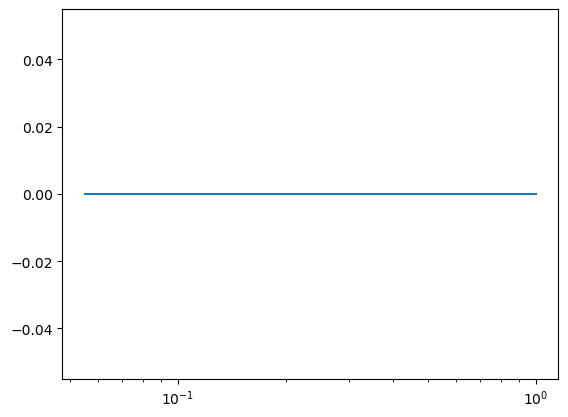

In [12]:
plt.figure()
plt.plot(ds['CUHSAS'+loc_tag].attrs['CellSizes'],ds['CUHSAS'+loc_tag].values[1100,0,:])
plt.xscale('log')

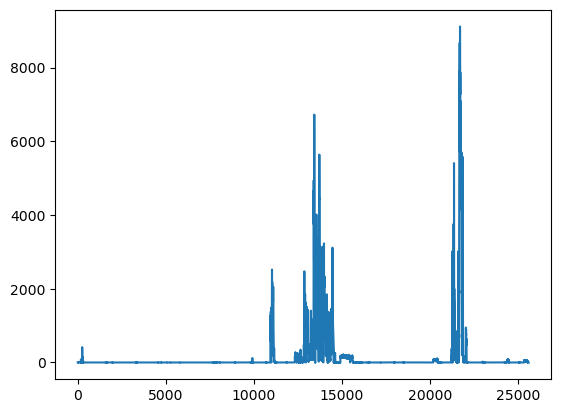

In [13]:
plt.figure()
plt.plot(np.sum(ds['CUHSAS'+loc_tag].values[:,0,:],axis=1))

In [14]:
part_diam = ds['CUHSAS'+loc_tag].attrs['CellSizes']*1e-6

In [15]:
# wavelen = 532e-9
wavelen_lst = [1064e-9, 532e-9, 355e-9]
wavelen_color = ['tab:red','tab:green','tab:purple']
index_refrac = 1.5

In [16]:
r_arr = part_diam/2
ang_arr = np.linspace(0,500e-6,100)
dang=np.diff(ang_arr)

In [17]:
solid_angle = 2*np.pi*np.trapz(np.sin(ang_arr),ang_arr)

In [18]:
r_mat, ang_mat = np.meshgrid(r_arr,ang_arr)

In [19]:
sig_pi = np.zeros((len(wavelen_lst),r_arr.size))
sig_e = np.zeros((len(wavelen_lst),r_arr.size))

for wl_idx, wavelen in enumerate(wavelen_lst):
    k_num = 2*np.pi/wavelen
    for r_idx,r_val in enumerate(r_arr):
        x_val = 2*np.pi*r_val/wavelen
        Fmat = mie.Mie_PhaseMatrix(index_refrac, x_val, np.pi+ang_arr)
        sig_pi[wl_idx,r_idx] = np.real(1/k_num**2*2*np.pi*np.trapz(Fmat[0,:]*np.sin(ang_arr),ang_arr))
        sig_e[wl_idx,r_idx] = np.real(mie.CrossSections(index_refrac,x_val)[0])*(np.pi*r_val**2)/2

In [32]:
1/k_num**2*2*np.pi*Fmat[0,0]

(3.0803076097698137e-12-2.5739588562565616e-30j)

In [34]:
sig_pi[-1,-1]/solid_angle

4.902430013891568e-13

Text(0, 0.5, 'Scattering Cross Section [$m^{-2}$]')

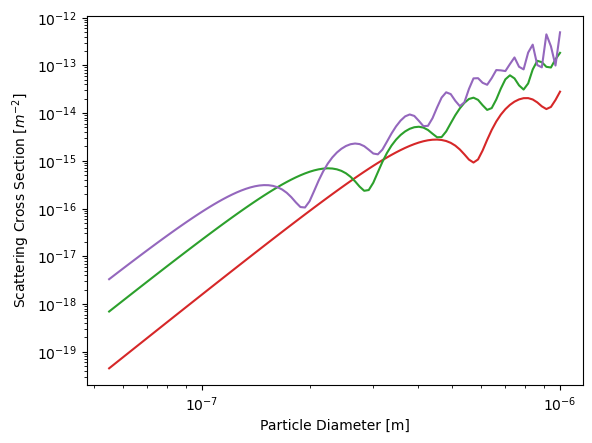

In [33]:
plt.figure()
for wl_idx, wavelen in enumerate(wavelen_lst):
    plt.plot(2*r_arr,sig_pi[wl_idx,:]/solid_angle,color=wavelen_color[wl_idx])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Particle Diameter [m]')
plt.ylabel('Scattering Cross Section [$m^{-2}$]')

In [79]:
beta_coef = np.zeros((len(wavelen_lst),ds['Time'].size))
alpha_coef = np.zeros((len(wavelen_lst),ds['Time'].size))
for idx in range(len(wavelen_lst)):
    beta_coef[idx,:] = np.trapz(ds['CUHSAS'+loc_tag].values.squeeze()*1e6*sig_pi[idx,:][np.newaxis,:],axis=1)/solid_angle
    alpha_coef[idx,:] = np.trapz(ds['CUHSAS'+loc_tag].values.squeeze()*1e6*sig_e[idx,:][np.newaxis,:],axis=1)
number_conc = np.trapz(ds['CUHSAS'+loc_tag].values.squeeze(),axis=1)
mean_r = np.trapz(ds['CUHSAS'+loc_tag].values.squeeze()*r_arr[np.newaxis,:],axis=1)/number_conc
mean_ln_r = np.trapz(ds['CUHSAS'+loc_tag].values.squeeze()*np.log10(r_arr[np.newaxis,:]),axis=1)/number_conc
std_ln_r = np.sqrt(np.trapz(ds['CUHSAS'+loc_tag].values.squeeze()*np.log10(r_arr[np.newaxis,:])**2,axis=1)/number_conc - mean_ln_r**2)


/tmp/ipykernel_821494/4268155425.py:7: RuntimeWarning: invalid value encountered in divide
  mean_r = np.trapz(ds['CUHSAS'+loc_tag].values.squeeze()*r_arr[np.newaxis,:],axis=1)/number_conc
/tmp/ipykernel_821494/4268155425.py:8: RuntimeWarning: invalid value encountered in divide
  mean_ln_r = np.trapz(ds['CUHSAS'+loc_tag].values.squeeze()*np.log10(r_arr[np.newaxis,:]),axis=1)/number_conc
/tmp/ipykernel_821494/4268155425.py:9: RuntimeWarning: invalid value encountered in divide
  std_ln_r = np.sqrt(np.trapz(ds['CUHSAS'+loc_tag].values.squeeze()*np.log10(r_arr[np.newaxis,:])**2,axis=1)/number_conc - mean_ln_r**2)
/tmp/ipykernel_821494/4268155425.py:9: RuntimeWarning: invalid value encountered in sqrt
  std_ln_r = np.sqrt(np.trapz(ds['CUHSAS'+loc_tag].values.squeeze()*np.log10(r_arr[np.newaxis,:])**2,axis=1)/number_conc - mean_ln_r**2)


Text(0, 0.5, 'mean log radius')

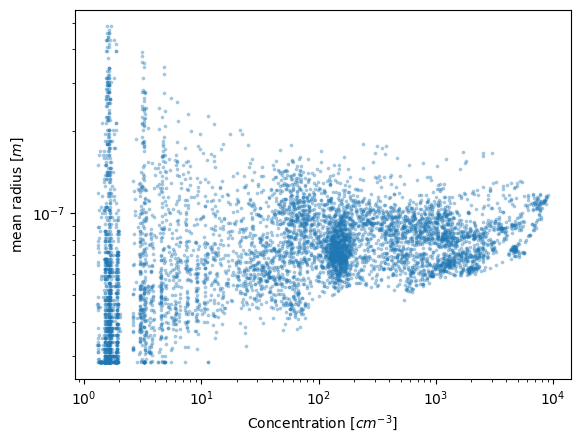

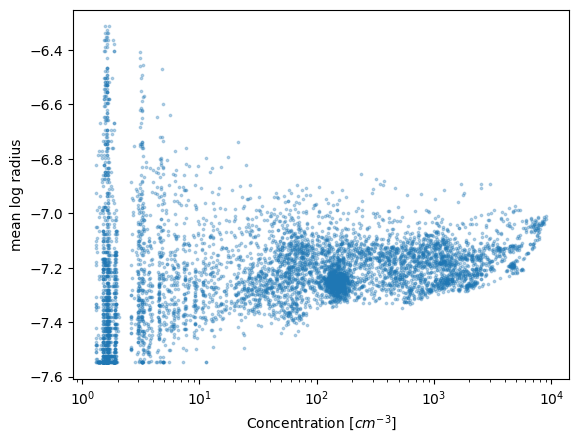

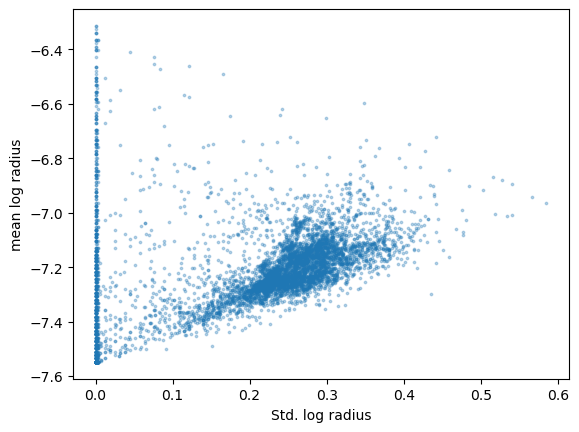

In [22]:
plt.figure()
plt.scatter(number_conc,mean_r,s=3,alpha=0.3)
plt.xlabel('Concentration [$cm^{-3}$]')
plt.ylabel('mean radius [$m$]')
plt.xscale('log')
plt.yscale('log')

plt.figure()
plt.scatter(number_conc,mean_ln_r,s=3,alpha=0.3)
plt.xlabel('Concentration [$cm^{-3}$]')
plt.ylabel('mean log radius')
plt.xscale('log')


plt.figure()
plt.scatter(std_ln_r,mean_ln_r,s=3,alpha=0.3)
plt.xlabel('Std. log radius')
plt.ylabel('mean log radius')

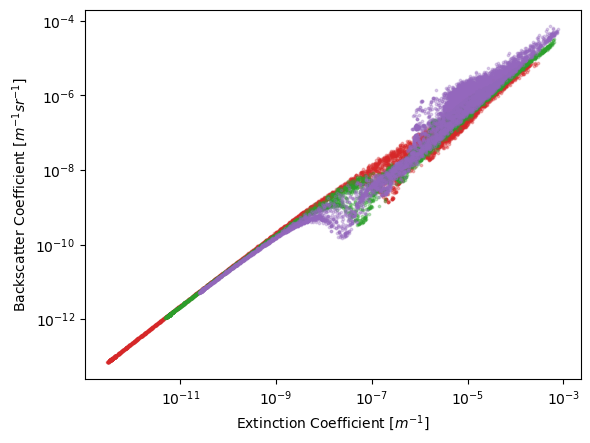

In [23]:
plt.figure()
for idx in range(len(wavelen_lst)):
    plt.scatter(alpha_coef[idx,:],beta_coef[idx,:],s=3,alpha=0.3,c=wavelen_color[idx])
plt.xlabel("Extinction Coefficient [$m^{-1}$]")
plt.ylabel("Backscatter Coefficient [$m^{-1}sr^{-1}$]")
plt.xscale('log')
plt.yscale('log')

Text(0, 0.5, 'Extinction Coefficient [$m^{-1}$]')

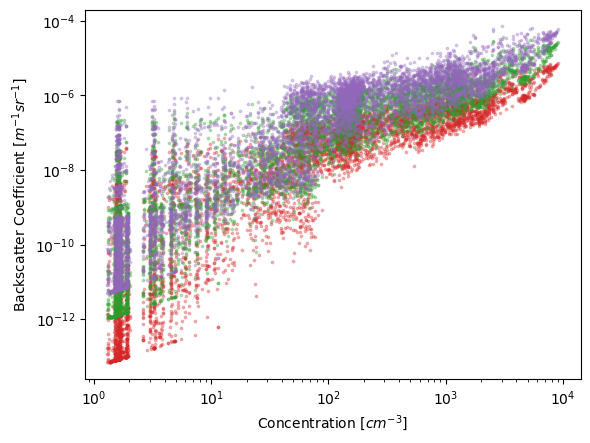

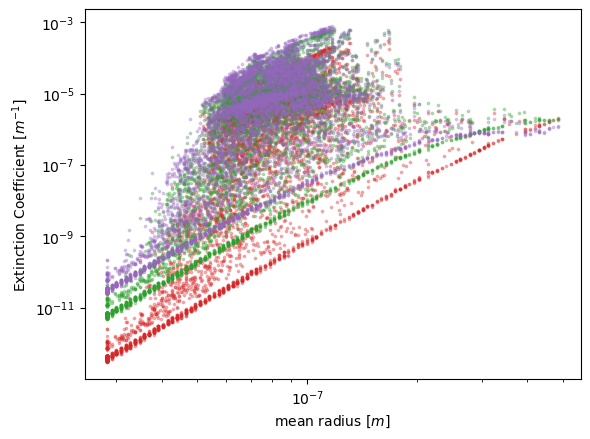

In [24]:
plt.figure()
for idx in range(len(wavelen_lst)):
    plt.scatter(number_conc,beta_coef[idx,:],s=3,alpha=0.3,c=wavelen_color[idx])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Concentration [$cm^{-3}$]')
plt.ylabel("Backscatter Coefficient [$m^{-1}sr^{-1}$]")

plt.figure()
for idx in range(len(wavelen_lst)):
    plt.scatter(mean_r,alpha_coef[idx,:],s=3,alpha=0.3,c=wavelen_color[idx])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('mean radius [$m$]')
plt.ylabel("Extinction Coefficient [$m^{-1}$]")

ValueError: x and y must have same first dimension, but have shapes (100,) and (3, 100)

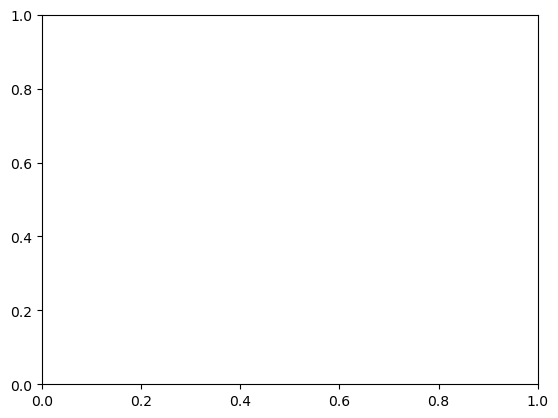

In [25]:
plt.figure()
plt.plot(r_arr,sig_pi/500e-6/2/np.pi)

In [80]:
# wavelen = 532e-9
# wavelen_lst = [1064e-9, 532e-9, 355e-9]
# wavelen_color = ['tab:red','tab:green','tab:purple']
wavelen_lst = [1064e-9, 532e-9, 355e-9]
wavelen_color = ['tab:red', 'tab:green','tab:purple']
index_refrac = 1.5

In [81]:
number_conc_lst = []
mean_r_lst = []
mean_ln_r_lst = []
std_ln_r_lst = []
beta_coef_lst = []
alpha_coef_lst = []

aircraft_vars = ['GGLAT','GGLON','GGALT','Time']
aircraft_vars_dct = {}
for var in aircraft_vars:
    aircraft_vars_dct[var] = []


# postfix = 'RWOOU'  # CSET
postfix = 'CVIU'   # SOCRATES
# postfix = 'RWI'  # HIPPO-1, HIPPO-2, HIPPO-3, HIPPO-4, HIPPO-5

# TODO also read in GGLAT, GGLON, GGALT

# file_lst = cset_lst
file_lst = socrates_lst[4:5]
# file_lst = hippo1_lst
# file_lst = hippo2_lst
# file_lst = hippo4_lst
# file_lst = hippo5_lst

load_params = True

for fidx,file in enumerate(file_lst):
    ds = xr.open_dataset(file)
    load_file = True
    
    if load_params:
        # run all the initial calculations
        try:
            part_diam = ds['CUHSAS_'+postfix].attrs['CellSizes']*1e-6
            load_params = False
            r_arr = part_diam/2
            ang_arr = np.linspace(0,500e-6,100)
            dang=np.diff(ang_arr)
            solid_angle = 2*np.pi*np.trapz(np.sin(ang_arr),ang_arr)
            r_mat, ang_mat = np.meshgrid(r_arr,ang_arr)
    
            sig_pi = np.zeros((len(wavelen_lst),r_arr.size))
            sig_e = np.zeros((len(wavelen_lst),r_arr.size))
            
            for wl_idx, wavelen in enumerate(wavelen_lst):
                k_num = 2*np.pi/wavelen
                for r_idx,r_val in enumerate(r_arr):
                    x_val = 2*np.pi*r_val/wavelen
                    Fmat = mie.Mie_PhaseMatrix(index_refrac, x_val, np.pi+ang_arr)
                    sig_pi[wl_idx,r_idx] = np.real(1/k_num**2*2*np.pi*np.trapz(Fmat[0,:]*np.sin(ang_arr),ang_arr))
                    sig_e[wl_idx,r_idx] = np.real(mie.CrossSections(index_refrac,x_val)[0])*(np.pi*r_val**2)/2
        except KeyError:
            load_file = False

    # skip loading the data if there is no UHSAS data
    if load_file:
        # dataset calculations
        beta_coef = np.zeros((len(wavelen_lst),ds['Time'].size))
        alpha_coef = np.zeros((len(wavelen_lst),ds['Time'].size))
        for idx in range(len(wavelen_lst)):
            beta_coef[idx,:] = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*1e6*sig_pi[idx,:][np.newaxis,:],axis=1)/solid_angle
            alpha_coef[idx,:] = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*1e6*sig_e[idx,:][np.newaxis,:],axis=1)
        number_conc = np.trapz(ds['CUHSAS_'+postfix].values.squeeze(),axis=1)
        
        mean_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:],axis=1)/number_conc
        mean_ln_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:]),axis=1)/number_conc
        std_ln_r = np.sqrt(np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:])**2,axis=1)/number_conc - mean_ln_r**2)
    
        valid_idx = np.where(number_conc > 0)  # locate and only use cases where the concentration is > 0
        for var in aircraft_vars_dct:
            aircraft_vars_dct[var].append(ds[var].values[valid_idx[0]])
    
        beta_coef_lst.append(beta_coef[:,valid_idx[0]])
        alpha_coef_lst.append(alpha_coef[:,valid_idx[0]])
        number_conc_lst.append(number_conc[valid_idx[0]])
        mean_r_lst.append(mean_r[valid_idx[0]])
        mean_ln_r_lst.append(mean_ln_r[valid_idx[0]])
        std_ln_r_lst.append(std_ln_r[valid_idx[0]])



/tmp/ipykernel_821494/1589630832.py:67: RuntimeWarning: invalid value encountered in divide
  mean_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:],axis=1)/number_conc
/tmp/ipykernel_821494/1589630832.py:68: RuntimeWarning: invalid value encountered in divide
  mean_ln_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:]),axis=1)/number_conc
/tmp/ipykernel_821494/1589630832.py:69: RuntimeWarning: invalid value encountered in divide
  std_ln_r = np.sqrt(np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:])**2,axis=1)/number_conc - mean_ln_r**2)
/tmp/ipykernel_821494/1589630832.py:69: RuntimeWarning: invalid value encountered in sqrt
  std_ln_r = np.sqrt(np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:])**2,axis=1)/number_conc - mean_ln_r**2)


In [82]:
file

'/scr/raf/Prod_Data/SOCRATES/SOCRATESrf05.nc'

In [83]:
beta_coef[:,valid_idx[0]].shape

(3, 6198)

In [84]:
beta_coef_arr = np.concatenate(beta_coef_lst,axis=1)
alpha_coef_arr = np.concatenate(alpha_coef_lst,axis=1)
number_conc_arr = np.concatenate(number_conc_lst,axis=0)
mean_r_arr = np.concatenate(mean_r_lst,axis=0)
mean_ln_r_arr = np.concatenate(mean_ln_r_lst,axis=0)
std_ln_r_arr = np.concatenate(std_ln_r_lst,axis=0)

aircraft_vars_arr_dct = {}
for var in aircraft_vars_dct:
    aircraft_vars_arr_dct[var] = np.concatenate(aircraft_vars_dct[var],axis=0)

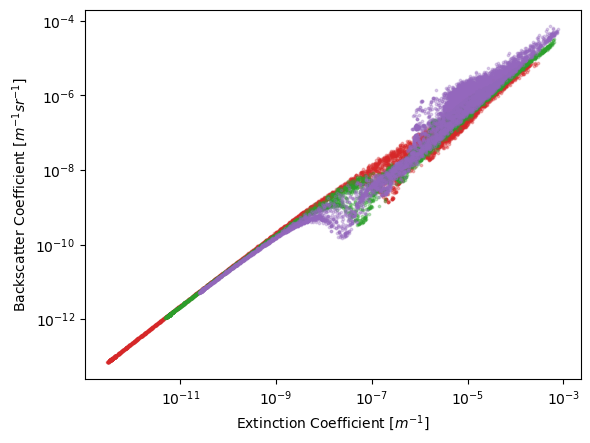

In [85]:
plt.figure()
for idx in range(len(wavelen_lst)):
    plt.scatter(alpha_coef[idx,:],beta_coef[idx,:],s=3,alpha=0.3,c=wavelen_color[idx])
plt.xlabel("Extinction Coefficient [$m^{-1}$]")
plt.ylabel("Backscatter Coefficient [$m^{-1}sr^{-1}$]")
plt.xscale('log')
plt.yscale('log')

In [104]:
# pick a random point above the noise floor
pt_idx = np.random.choice(np.arange(number_conc_arr.size)[np.where(~np.isnan(number_conc_arr)&(number_conc_arr>1)&(beta_coef_arr[idx,:]>1e-8))])

# pick a random point
# pt_idx = np.random.choice(np.arange(number_conc_arr.size)[np.where(~np.isnan(number_conc_arr)&(number_conc_arr>1))])

In [105]:
pt_idx

3832

Text(0, 0.5, 'Backscatter Coefficient [$m^{-1}sr^{-1}$]')

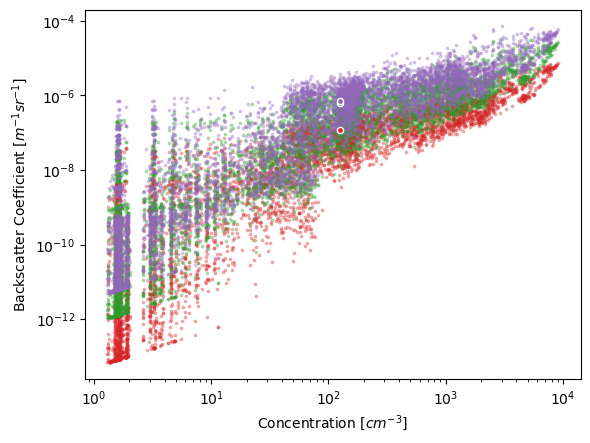

In [106]:
plt.figure()
for idx in range(len(wavelen_lst)):
    plt.scatter(number_conc_arr,beta_coef_arr[idx,:],s=3,alpha=0.3,c=wavelen_color[idx])
for idx in range(len(wavelen_lst)):    
    plt.scatter(number_conc_arr[pt_idx],beta_coef_arr[idx,pt_idx],s=20,c=wavelen_color[idx],linewidths=1,edgecolors="w")
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Concentration [$cm^{-3}$]')
plt.ylabel("Backscatter Coefficient [$m^{-1}sr^{-1}$]")

# plt.figure()
# for idx in range(len(wavelen_lst)):
#     plt.scatter(mean_r,alpha_coef[idx,:],s=3,alpha=0.3)
# plt.xscale('log')
# plt.yscale('log')
# plt.xlabel('mean radius [$m$]')
# plt.ylabel("Extinction Coefficient [$m^{-1}$]")

In [107]:
number_conc_arr[pt_idx]

126.323685

This analysis is for absolute knowledge of coefficients.  What about relative knowledge of backscatter?

Instead of mu and std, what about doing cumulative bounds on 10% and 90%?

In [108]:
percentile_arr = np.array([0.05,0.5,0.95])

h_conc_beta_lst = []
h_conc_alpha_lst = []
cum_where_arg = np.ones(beta_coef_arr[0,:].size,dtype=bool)
bs_where_arg = np.ones(beta_coef_arr[0,:].size,dtype=bool)
for idx in range(len(wavelen_lst)):
    print(f"{wavelen_lst[idx]*1e9:f} beta: {beta_coef_arr[idx,pt_idx]:.2e}")
    print(f"{wavelen_lst[idx]*1e9:f} alpha: {alpha_coef_arr[idx,pt_idx]:.2e}")
    idx_backscat = np.where(np.abs(np.log10(beta_coef_arr[idx,:])-np.log10(beta_coef_arr[idx,pt_idx])) < 0.1)
    cum_where_arg = cum_where_arg & (np.abs(np.log10(beta_coef_arr[idx,:])-np.log10(beta_coef_arr[idx,pt_idx])) < 0.1)
    bs_where_arg = bs_where_arg & (np.abs(np.log10(beta_coef_arr[idx,:])-np.log10(beta_coef_arr[idx,pt_idx])) < 0.1)
    idx_extinct = np.where(np.abs(np.log10(alpha_coef_arr[idx,:])-np.log10(alpha_coef_arr[idx,pt_idx])) < 0.1)
    cum_where_arg = cum_where_arg & (np.abs(np.log10(alpha_coef_arr[idx,:])-np.log10(alpha_coef_arr[idx,pt_idx])) < 0.1)
    conc_set_beta = number_conc_arr[idx_backscat]
    conc_set_alpha = number_conc_arr[idx_extinct]
    h_conc_beta = np.histogram(conc_set_beta,bins=np.logspace(0,4))
    h_conc_alpha = np.histogram(conc_set_alpha,bins=np.logspace(0,4))
    h_conc_beta_lst.append(h_conc_beta)
    h_conc_alpha_lst.append(h_conc_alpha)
total_case_count = np.sum(cum_where_arg)
conc_set_total = number_conc_arr[np.where(cum_where_arg)]
conc_log_std = np.std(np.log(conc_set_total))
conc_log_mean = np.mean(np.log(conc_set_total))
h_total = np.histogram(conc_set_total,bins=np.logspace(0,4))
h_total_cum = np.cumsum(h_total[0]/np.sum(h_total[0]))
h_percentile = np.interp(percentile_arr,h_total_cum,h_total[1][1:])

bs_case_count = np.sum(bs_where_arg)
conc_set_bs = number_conc_arr[np.where(bs_where_arg)]
conc_bs_log_std = np.std(np.log(conc_set_bs))
conc_bs_log_mean = np.mean(np.log(conc_set_bs))
h_bs = np.histogram(conc_set_bs,bins=np.logspace(0,4))
h_bs_cum = np.cumsum(h_bs[0]/np.sum(h_bs[0]))
h_bs_percentile = np.interp(percentile_arr,h_bs_cum,h_bs[1][1:])

print(conc_log_std)
print(conc_log_mean)
print(h_percentile)
print(h_bs_percentile)
print(total_case_count)
print(bs_case_count)

1064.000000 beta: 1.19e-07
1064.000000 alpha: 4.81e-06
532.000000 beta: 6.43e-07
532.000000 alpha: 8.21e-06
355.000000 beta: 7.14e-07
355.000000 alpha: 6.25e-06
0.30586803
4.9059486
[ 57.95344096 145.13622362 185.46047567]
[ 57.15013302 147.08482001 868.51137375]
23
40


Text(0, 0.5, 'Cumulative Likelihood')

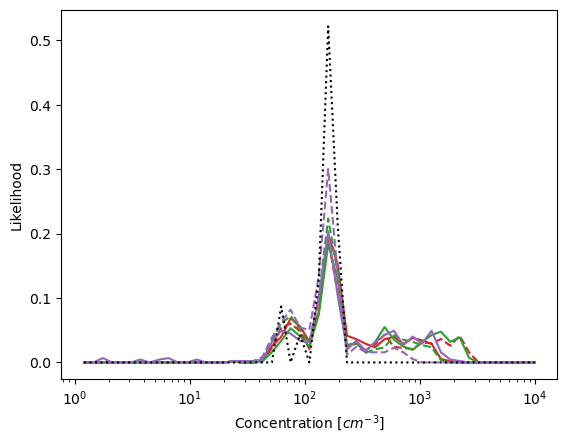

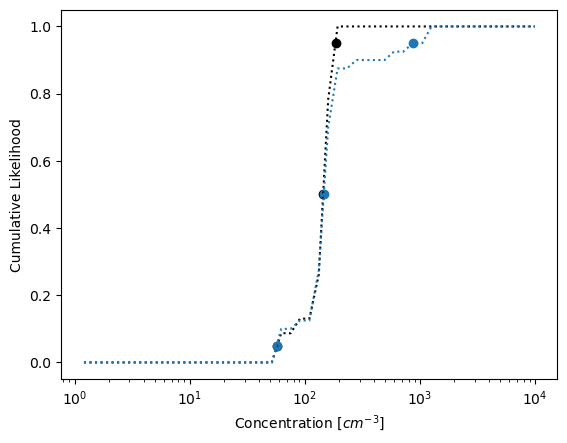

In [109]:
# h_total = np.ones(h_conc_beta_lst[0][0].size)
plt.figure()
for idx in range(len(wavelen_lst)):
    plt.plot(h_conc_beta_lst[idx][1][1:],h_conc_beta_lst[idx][0]/np.sum(h_conc_beta_lst[idx][0]),color=wavelen_color[idx])
    plt.plot(h_conc_alpha_lst[idx][1][1:],h_conc_alpha_lst[idx][0]/np.sum(h_conc_alpha_lst[idx][0]),color=wavelen_color[idx],linestyle='--')
    # likelihood total assumes the PDFs are uncorrelated which they probably aren't
    # need to use Bayes theorem to calculate the joint PDF
    # h_total *= (h_conc_alpha_lst[idx][0]/np.sum(h_conc_alpha_lst[idx][0]))*(h_conc_beta_lst[idx][0]/np.sum(h_conc_beta_lst[idx][0]))

plt.plot(h_total[1][1:],h_total[0]/np.sum(h_total[0]),color="k",linestyle=':')
plt.xscale('log')
plt.xlabel('Concentration [$cm^{-3}$]')
plt.ylabel('Likelihood')

plt.figure()
plt.plot(h_total[1][1:],np.cumsum(h_total[0]/np.sum(h_total[0])),color="k",linestyle=':')
plt.scatter(h_percentile,percentile_arr,c="k")

plt.plot(h_total[1][1:],np.cumsum(h_bs[0]/np.sum(h_bs[0])),color="tab:blue",linestyle=':')
plt.scatter(h_bs_percentile,percentile_arr,c="tab:blue")

plt.xscale('log')
plt.xlabel('Concentration [$cm^{-3}$]')
plt.ylabel('Cumulative Likelihood')

0.30586803


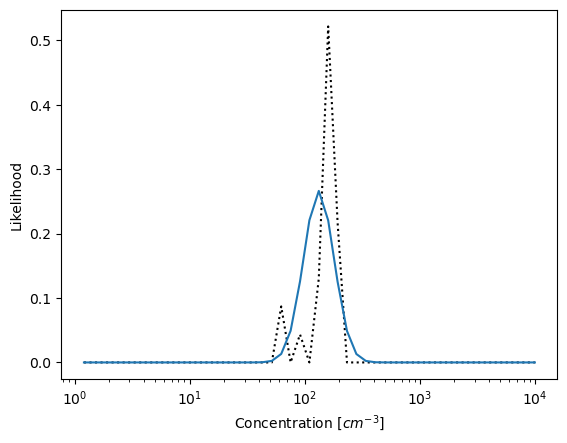

In [111]:
log_norm = 1/np.log(h_total[1][1:])/np.sqrt(conc_log_std**2*np.pi*2) * np.exp(-(np.log(h_total[1][1:])-conc_log_mean)**2/(2*conc_log_std**2))
plt.figure()
plt.plot(h_total[1][1:],h_total[0]/np.sum(h_total[0]),color="k",linestyle=':')
plt.plot(h_total[1][1:],log_norm)
plt.xscale('log')
plt.xlabel('Concentration [$cm^{-3}$]')
plt.ylabel('Likelihood')
print(conc_log_std)

In [116]:
np.where(~np.isnan(number_conc_arr)&(number_conc_arr>0)&(beta_coef_arr[idx,:]>1e-8))[0].size

4192

In [117]:
beta_precision = 0.1
alpha_precision = 0.1
percentile_arr = np.array([0.05,0.5,0.95])
sample_count = 1000 # 5000 # number of points to sample in analysis

conc_log_std_lst = []
conc_log_mean_lst = []
beta_coef_set_lst = []
alpha_coef_set_lst = []
cum_percentile_lst = []
cum_case_cnt_lst = []

pt_idx_lst = np.random.choice(np.arange(number_conc_arr.size)[np.where(~np.isnan(number_conc_arr)&(number_conc_arr>0)&(beta_coef_arr[idx,:]>1e-8))],size=sample_count,replace=False)
# pt_idx_lst = np.random.choice(np.arange(number_conc_arr.size)[np.where(~np.isnan(number_conc_arr)&(number_conc_arr>0))],size=sample_count,replace=False)
for iter_idx,pt_idx in enumerate(pt_idx_lst):
    h_conc_beta_lst = []
    h_conc_alpha_lst = []
    cum_where_arg = np.ones(beta_coef_arr[0,:].size,dtype=bool)
    for idx in range(len(wavelen_lst)):
        idx_backscat = np.where(np.abs(np.log10(beta_coef_arr[idx,:])-np.log10(beta_coef_arr[idx,pt_idx])) < beta_precision)
        cum_where_arg = cum_where_arg & (np.abs(np.log10(beta_coef_arr[idx,:])-np.log10(beta_coef_arr[idx,pt_idx])) < beta_precision)
        idx_extinct = np.where(np.abs(np.log10(alpha_coef_arr[idx,:])-np.log10(alpha_coef_arr[idx,pt_idx])) < alpha_precision)
        cum_where_arg = cum_where_arg & (np.abs(np.log10(alpha_coef_arr[idx,:])-np.log10(alpha_coef_arr[idx,pt_idx])) < alpha_precision)
        conc_set_beta = number_conc_arr[idx_backscat]
        conc_set_alpha = number_conc_arr[idx_extinct]
        
        h_conc_beta = np.histogram(conc_set_beta,bins=np.logspace(0,4))
        h_conc_alpha = np.histogram(conc_set_alpha,bins=np.logspace(0,4))
        h_conc_beta_lst.append(h_conc_beta)
        h_conc_alpha_lst.append(h_conc_alpha)
        
    total_case_count = np.sum(cum_where_arg)
    beta_coef_set_lst.append(beta_coef_arr[:,pt_idx])
    alpha_coef_set_lst.append(alpha_coef_arr[:,pt_idx])
    conc_set_total = number_conc_arr[np.where(cum_where_arg)]
    conc_log_std = np.std(np.log(conc_set_total))
    conc_log_mean = np.mean(np.log(conc_set_total))
    h_total = np.histogram(conc_set_total,bins=np.logspace(0,4))
    h_total_cum = np.cumsum(h_total[0]/np.sum(h_total[0]))
    h_percentile = np.interp(percentile_arr,h_total_cum,h_total[1][1:])
    conc_log_std_lst.append(conc_log_std)
    conc_log_mean_lst.append(conc_log_mean)
    cum_percentile_lst.append(h_percentile)
    cum_case_cnt_lst.append(total_case_count)

In [118]:
cum_percentile_arr = np.stack(cum_percentile_lst,axis=1)

In [119]:
cum_percentile_arr.shape

(3, 1000)

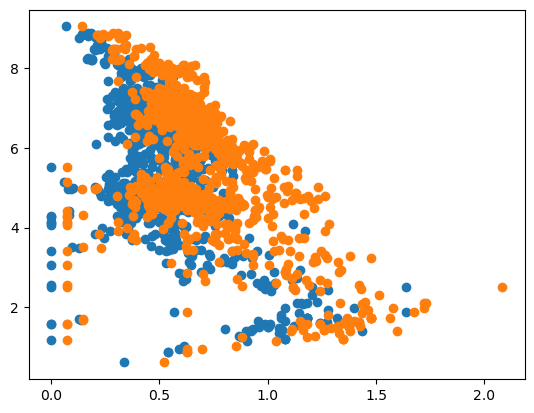

In [120]:
plt.figure()
plt.scatter(conc_log_std_lst,conc_log_mean_lst)
plt.scatter(np.log10(cum_percentile_arr[2,:]/cum_percentile_arr[0,:]),conc_log_mean_lst)

In [49]:
np.sum(cum_percentile_arr[2,:] < cum_percentile_arr[0,:])

0

Text(0, 0.5, '$\\mu$ [$cm^{-3}$]')

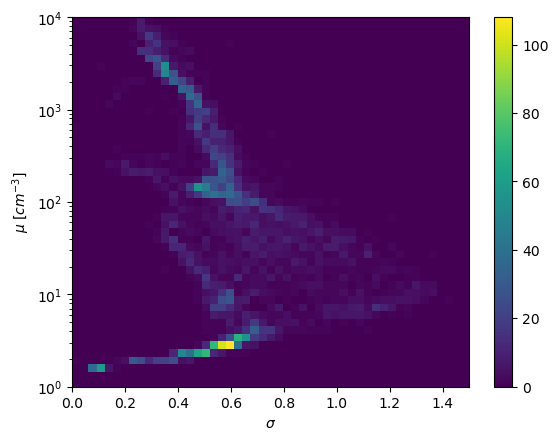

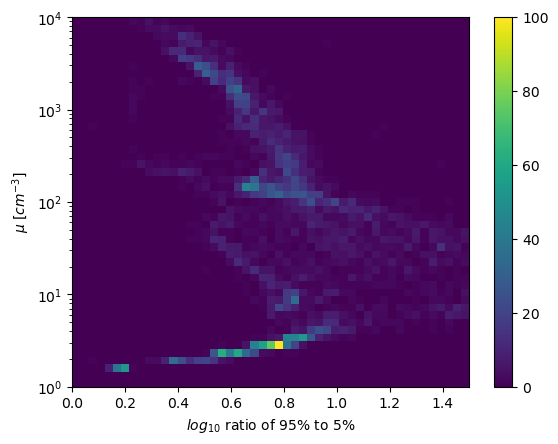

In [50]:
hist_m_s = np.histogram2d(conc_log_std_lst,np.exp(np.array(conc_log_mean_lst)),bins=(np.linspace(0,1.5,50),np.logspace(0,4,50)))
plt.figure()
plt.pcolormesh(hist_m_s[1],hist_m_s[2],hist_m_s[0].T)
plt.colorbar()
plt.yscale('log')
plt.xlabel("$\sigma$")
plt.ylabel("$\mu$ [$cm^{-3}$]")

hist_m_s = np.histogram2d(np.log10(cum_percentile_arr[2,:]/cum_percentile_arr[0,:]),np.exp(np.array(conc_log_mean_lst)),bins=(np.linspace(0,1.5,50),np.logspace(0,4,50)))
plt.figure()
plt.pcolormesh(hist_m_s[1],hist_m_s[2],hist_m_s[0].T)
plt.colorbar()
plt.yscale('log')
plt.xlabel("$log_{10}$ ratio of 95% to 5%")
plt.ylabel("$\mu$ [$cm^{-3}$]")

In [304]:
conc_log_std_lst

[0.20794475,
 0.0,
 0.1587368,
 0.09939044,
 0.0,
 0.19398262,
 0.0,
 0.0,
 0.0,
 0.11703622,
 0.0,
 0.014521122,
 0.19028553,
 0.23001151,
 0.0,
 0.2917289,
 0.0,
 0.22011748,
 0.16416311,
 0.0,
 0.1803916,
 0.0,
 0.0,
 0.0,
 0.0,
 0.20353949,
 0.0,
 0.14222506,
 0.1460523,
 0.0,
 0.0030748844,
 0.0,
 0.2588635,
 0.18567885,
 0.0,
 0.0,
 0.077059984,
 0.0,
 0.1251303,
 0.12647013,
 0.0,
 0.0,
 0.13220878,
 0.0,
 0.0,
 0.0,
 0.0,
 0.16662908,
 0.0,
 0.20604236,
 7.796324e-05,
 0.18660338,
 0.020368338,
 0.0,
 0.40772375,
 0.09897368,
 0.35803548,
 0.10013545,
 0.0,
 0.23487525,
 0.67417365,
 0.0,
 0.0,
 0.10016582,
 0.0,
 0.0,
 0.49460527,
 0.3000601,
 0.2961893,
 0.0,
 0.33776134,
 0.0,
 0.19369063,
 0.1545342,
 0.23001324,
 0.0,
 0.0,
 0.85465515,
 0.0,
 0.31918344,
 0.4291171,
 0.0,
 0.0,
 0.17817251,
 0.14302729,
 0.020832777,
 0.0,
 0.040221214,
 0.00043749815,
 0.0,
 0.15401804,
 0.41601,
 0.0,
 0.057032347,
 0.24234171,
 0.0,
 0.0,
 0.0,
 0.0,
 0.18893097,
 0.20155954,
 0.198765

In [281]:
beta_coef_set_arr = np.stack(beta_coef_set_lst,axis=1)
alpha_coef_set_arr = np.stack(alpha_coef_set_lst,axis=1)

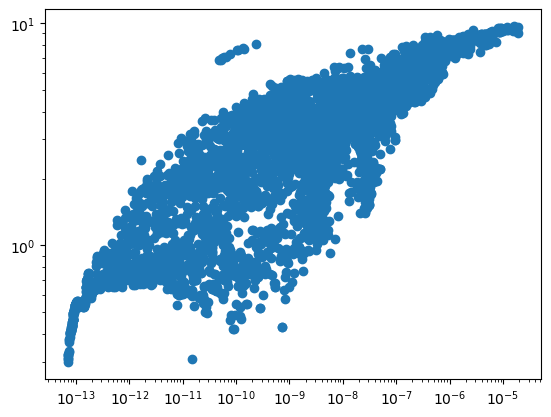

In [288]:
plt.figure()
plt.scatter(beta_coef_set_arr[0,:],conc_log_mean_lst)
# plt.scatter(beta_coef_set_arr[1,:],conc_log_std_lst)
# plt.scatter(beta_coef_set_arr[2,:],conc_log_std_lst)
plt.yscale('log')
plt.xscale('log')

In [268]:
number_conc_arr[pt_idx]

1.7431536

In [203]:
max(conc_log_std_lst)

0.3193608

In [ ]:
# test_ang_arr = np.linspace(0,180,1000)*np.pi/180
# Fmat = mie.Mie_PhaseMatrix(index_refrac, x_val, test_ang_arr)